In [29]:
import wave 
import pyroomacoustics as pa
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp
import scipy
import time

from calc_steering_vector import calculate_steering_vector

In [30]:
def write_file_from_time_signal(data, save_path, sample_rate):
    data = data.astype(np.int16)
    save_file = wave.open(save_path, 'w')
    save_file.setnchannels(1)
    save_file.setsampwidth(2)
    save_file.setframerate(sample_rate)
    save_file.writeframes(data)
    save_file.close()

In [31]:
def save_spectrogram_img(data, save_path, sample_rate, fft_size, noverlap):
    # スペクトログラムをプロットする
    fig = plt.figure(figsize=(10, 4))
    # スペクトログラムを表示する
    spectrum, freqs, t, im = plt.specgram(data, NFFT=fft_size, noverlap=noverlap, Fs=sample_rate)
    # カラーバーを表示する
    fig.colorbar(im).set_label('Intensity [dB]')
    # x軸のラベル
    plt.xlabel("Time [sec]")
    # y軸のラベル
    plt.ylabel("Frequency [Hz]")
    # 音声ファイルを画像として保存
    plt.savefig(save_path)

In [32]:
# クロネッカー積を用いた計算
def batch_kron(A, B):
    if np.shape(A)[:-2] != np.shape(B)[:-2]:
        print("error")
        return None
    else:
        return(np.reshape(np.einsum('...mn,...ij->...minj', A, B), np.shape(A)[:-2] + (np.shape(A)[-2]*np.shape(B)[-2], np.shape(A)[-1]*np.shape(B)[-1])))

In [33]:
# 過去のマイクロホン入力信号の算出
def make_x_bar(x, D, Lh):
    """
    x: 入力信号 (num_microphones=2, freq_bins=513, time_frames=276)
    D: 遅延フレーム数
    Lh: 残響除去フィルタのタップ長
    x_bar: 過去のマイクロホン入力信号 (Lh, M, Nk, Lt)
    """
    # フレーム数を取得
    Lt = np.shape(x)[2]

    # 過去のマイクロホン入力信号の配列を準備
    x_bar = np.zeros(shape=(Lh,) + np.shape(x), dtype=np.complex)
    """x_bar: (tap_length, num_microphones=2, freq_bins=513, time_frames=276)"""

    for tau in range(Lh):
        x_bar[tau, :, :, tau+D:] = x[:, :, :-(tau+D)]
    """x_bar: (tap_length, num_microphones, freq_bins, time_frames)"""
    return x_bar

In [34]:
# 時変ガウスモデルに基づく音源分離と残響除去の同時実行
def mm_lgm_dereverb(x, x_bar, Ns=2, n_iterations=20):
    """x: (num_microphones, freq_bins, time_frames)"""
    # マイクロホン数・周波数・フレーム数・タップ長を取得する
    M = np.shape(x)[0]
    Nk = np.shape(x)[1]
    Lt = np.shape(x)[2]
    Lh = np.shape(x_bar)[0]

    x_bar = np.reshape(x_bar, [Lh*M, Nk, Lt])
    """x_bar: (num_taps*num_microphones, freq_bins, time_frames)"""

    # Rとvを初期化する
    mask = np.random.uniform(size=Nk*Ns*Lt)
    mask = np.reshape(mask, (Nk, Ns, Lt))
    R = np.einsum('kst,mkt,nkt->kstmn', mask, x, np.conjugate(x))
    R = np.average(R, axis=2)
    v = np.random.uniform(size=Nk*Ns*Lt)
    v = np.reshape(v, (Nk, Ns, Lt))

    # 共分散行列を計算
    x_bar_x_bar_H = np.einsum('ikt,jkt->ktij', x_bar, np.conjugate(x_bar))
    """x_bar_x_bar_H: (freq_bins, time_frames, num_taps*num_microphones, num_taps*num_microphones)"""

    # 相関行列を計算
    x_bar_x_H = np.einsum('ikt,mkt->ktim', x_bar, np.conjugate(x))
    """x_bar_x_H: (freq_bins, time_frames, num_taps*num_microphones, num_microphones)"""

    cost_buff = []
    for t in range(n_iterations):
        # 入力信号の共分散行列を求める
        vR = np.einsum('kst,ksmn->kstmn', v, R)
        V = np.sum(vR, axis=1) # 音源数分の和をとる
        """V: (freq_bins, time_frames, num_microphones, num_microphones)"""
        V = V + np.eye(M, M) * 1.e-8 # 逆行列をとる際の計算上の不安定性を取り除く
        V_inverse = np.linalg.pinv(V)
        """V_inverse: (freq_bins, time_frames, num_microphones, num_microphones)"""

        # 残響除去フィルタを求める
        x_barx_H_V_inv = np.einsum('ktim,ktmn->kin', x_bar_x_H, V_inverse)
        """x_barx_H_V_inv: (freq_bins, num_taps*num_microphones, num_microphones)"""
        vec_x_bar_x_HV_inv = np.reshape(np.transpose(x_barx_H_V_inv, [0, 2, 1]), (Nk, Lh*M*M))
        V_inverse_x_x_H = batch_kron(np.transpose(V_inverse, (0, 1, 3, 2)), x_bar_x_bar_H)
        vec_h = np.einsum('kmr,kr->km', np.linalg.inv(np.sum(V_inverse_x_x_H, axis=1)), vec_x_bar_x_HV_inv)
        h = np.transpose(np.reshape(vec_h, (Nk, M, Lh*M)), (0, 2, 1)) # フィルタ算出
        """h: (freq_bins, num_taps*num_microphones, num_microphones)"""

        # 残響除去を行う
        x_reverb = np.einsum('kjm,jkt->mkt', np.conjugate(h), x_bar)
        """x_reverb: (num_microphones, freq_bins, time_frames)"""
        x_dereverb = x - x_reverb
        """x_dereverb: (num_microphones, freq_bins, time_frames)"""
        
        # コスト計算
        cost = np.sum(np.einsum('mkt,ktmn,nkt->kt', np.conjugate(x_dereverb), V_inverse, x_dereverb) + np.log(np.abs(np.linalg.det(V))))
        cost /= np.float(Lt)
        cost = np.real(cost)
        cost_buff.append(cost)

        # 音源分離のパラメータを更新
        # Rの更新
        V_inverseX = np.einsum('ktmn,nkt->ktm', V_inverse, x_dereverb) 
        V_inverseXV_inverse_X = np.einsum('ktm,ktn->ktmn', V_inverseX, np.conjugate(V_inverseX))
        A = np.einsum('kst,ktmn->ksmn', v, V_inverse)
        B = np.einsum('kst,ktmn->ksmn', v, V_inverseXV_inverse_X)
        RBR = np.einsum('ksmn,ksni,ksij->ksmj', R, B, R)
        invA = np.linalg.pinv(A)
        A_RBR = np.matmul(A, RBR)
        R = np.concatenate([np.concatenate([np.matmul(invA[k, s, :, :], scipy.linalg.sqrtm(A_RBR[k, s, :, :]))[None, None, ...] for k in range(Nk)], axis=0) for s in range(Ns)], axis=1)
        R = (R + np.transpose(np.conjugate(R), [0, 1, 3, 2])) / (2.0 + 0.0j)
        """R: (freq_bins, num_sources, num_microphones, num_microphones)"""
        # vの更新
        v = v * np.sqrt(np.einsum('ktm,ktn,ksnm->kst', V_inverseX, np.conjugate(V_inverseX), R) / np.maximum(np.einsum('ktmn,ksnm->kst', V_inverse, R), 1.e-18))
        """v: 時間周波数分散 (freq_bins, num_sources, time_frames)"""

    vR = np.einsum('kst,ksmn->kstmn', v, R)
    V = np.sum(vR, axis=1) # 音源数分の和をとる
    """V: (freq_bins, time_frames, num_microphones, num_microphones)"""
    V_inverse = np.linalg.pinv(V)
    Wmwf = np.einsum('kstmi,ktin->kstmn', vR, V_inverse)

    # 音源分離信号を得る
    c_bar = np.einsum('kstmn,nkt->mskt', Wmwf, x_dereverb)
    """c_bar: 音源分離信号 (num_microphones, num_sources, freq_bins, time_frames)"""

    return R, v, c_bar, cost_buff

処理時間： 37.052014038999914


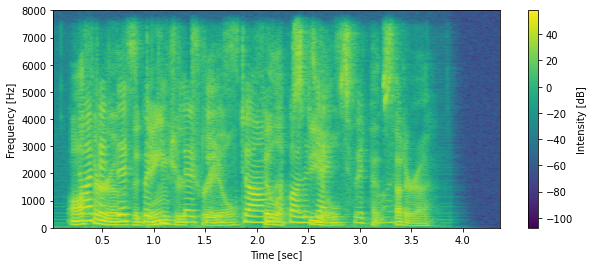

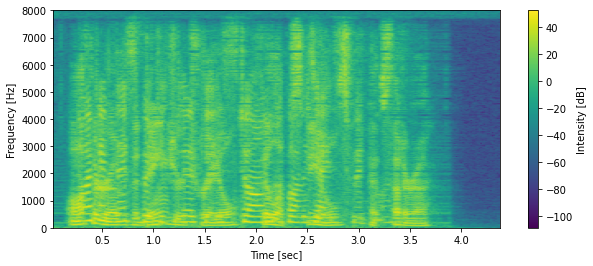

In [35]:
if __name__ == "__main__":
    # 乱数の種を初期化
    np.random.seed(0)
    # 畳み込みに用いる波形
    clean_wave_files = ["../Beamformer/CMU_ARCTIC/cmu_us_aew/wav/arctic_a0001.wav", "..//Beamformer/CMU_ARCTIC/cmu_us_axb/wav/arctic_a0002.wav"]
    # 雑音だけの区間のフレーム数
    n_noise_only = 40000
    # 音源数
    n_sources = len(clean_wave_files)
    # 音声波形の長さを調べる
    n_samples = 0
    # ファイルを読み込む
    for clean_wave_file in clean_wave_files:
        wav = wave.open(clean_wave_file)
        if n_samples<wav.getnframes():
            n_samples=wav.getnframes()
        wav.close()
    clean_data = np.zeros([n_sources, n_samples])

    # ファイルを読み込む
    s = 0
    for clean_wave_file in clean_wave_files:
        wav = wave.open(clean_wave_file)
        data = wav.readframes(wav.getnframes())
        data = np.frombuffer(data, dtype=np.int16)
        data = data/np.iinfo(np.int16).max
        clean_data[s, :wav.getnframes()] = data
        wav.close()
        s = s+1

    # シミュレーションのパラメータ
    n_sim_sources = 2
    # サンプリングレート [Hz]
    sample_rate = 16000
    # フレームサイズ
    N = 1024
    # フレームシフト
    Nshift = int(N/4)
    # 周波数の数
    Nk = N / 2 + 1
    # 各ビンの周波数
    freqs = np.arange(0, Nk, 1) * sample_rate / N
    # 生成した音が割れないようにするための振幅調整用パラメータ
    amp_decay = 20 
    # 音声と雑音の比率 [dB]
    SNR = 90.
    # 部屋の大きさ
    room_dim = np.r_[10.0, 10.0, 10.0]
    # マイクロホンアレイを置く部屋の場所
    mic_array_loc = room_dim / 2 + np.random.randn(3) * 0.1
    # マイクロホンアレイのマイクロホン配置
    mic_alignments = np.array(
            [[x, 0.0, 0.0] for x in np.arange(-0.01, 0.02, 0.02)]
    )
    # マイクロホン数
    n_channels = np.shape(mic_alignments)[0]
    # get the microphone array
    R  = mic_alignments.T + mic_array_loc[:, None]
    """R: (3D-coordinate(x,y,z)=3, num_microphones)"""
    # 部屋を生成する
    room = pa.ShoeBox(room_dim, fs=sample_rate, max_order=17, absorption=0.4)
    # room_no_noise = pa.ShoeBox(room_dim, fs=sample_rate, max_order=17, absorption=0.4)
    # 用いるマイクロホンアレイの情報を設置する
    room.add_microphone_array(pa.MicrophoneArray(R, fs=room.fs))
    # room_no_noise.add_microphone_array(pa.MicrophoneArray(R, fs=room.fs))
    # 音源の場所
    doas  = np.array(
        [[np.pi/2, 0],
        [np.pi/2, np.pi]]
        )
    # 音源とマイクロホンの距離
    distance = 1.
    source_locations = np.zeros((3, doas.shape[0]), dtype=doas.dtype)
    """source_locations: (xyz, num_sources)"""
    source_locations[0,  :] = np.cos(doas[:, 1]) * np.sin(doas[:, 0]) 
    source_locations[1,  :] = np.sin(doas[:, 1]) * np.sin(doas[:, 0])
    source_locations[2,  :] = np.cos(doas[:, 0])
    source_locations *= distance
    source_locations += mic_array_loc[:, None] # マイクロホンアレイからの相対位置→絶対位置
    # print("clean_data:", np.shape(clean_data))

    # 各音源をシミュレーションに追加する
    for s in range(n_sim_sources):
        clean_data[s] /= np.std(clean_data[s])
        room.add_source(source_locations[:, s], signal=clean_data[s])
        # if s == 0:
        #     room_no_noise.add_source(source_locations[:, s], signal=clean_data[s])

    # シミュレーションを回す
    room.simulate(snr=SNR)
    # room_no_noise.simulate(snr=90)

    # 畳み込んだ波形を取得する
    multi_conv_data = room.mic_array.signals
    """multi_conv_data: (num_channels, num_samples)"""
    # multi_conv_data_no_noise = room_no_noise.mic_array.signals
    # """multi_conv_data_no_noise: (num_channels, num_samples)"""

    # Near仮定に基づくステアリングベクトルを計算: steering_vectors(Nk × Ns × M)
    near_steering_vectors = calculate_steering_vector(R, source_locations, freqs,  is_use_far=False)
    """near_steering_vectors: (freq_bins, num_sources, num_microphones)"""

    # 処理前の音声をファイルに書き込む
    write_file_from_time_signal(multi_conv_data[0]*np.iinfo(np.int16).max/amp_decay, "./wav/original.wav", sample_rate)
    save_spectrogram_path = "./spectrogram/original.png"
    save_spectrogram_img(multi_conv_data[0]*np.iinfo(np.int16).max/amp_decay, save_spectrogram_path, sample_rate, fft_size=N, noverlap=N-Nshift)

    # 処理の開始時間
    start_time = time.perf_counter()

    # 短時間フーリエ変換
    f, t, stft_data = sp.stft(multi_conv_data, fs=sample_rate, window="hann", nperseg=N, noverlap=N-Nshift)
    """f: (freq_bins,), t: (1,), stft_data:(num_microphones, freq_bins, time_frames)"""

    # 過去のマイクロホン入力信号
    stft_data_past = make_x_bar(stft_data, D=2, Lh=5)

    # 時変ガウスモデルに基づく音源分離と残響除去の同時実行
    _, _, lgm_dereverb_out, _ = mm_lgm_dereverb(stft_data, stft_data_past, Ns=2, n_iterations=20)

    # 逆短時間フーリエ変換
    t, lgm_dereverb_out = sp.istft(lgm_dereverb_out[0][0], fs=sample_rate, window="hann", nperseg=N, noverlap=N-Nshift)

    # 処理の終了時間
    finish_time = time.perf_counter()
    print("処理時間：", finish_time - start_time)

    # 大きさを調整する
    lgm_dereverb_out = lgm_dereverb_out * np.iinfo(np.int16).max / amp_decay

    # ファイルに書き込む
    write_file_from_time_signal(lgm_dereverb_out, "./wav/lgm_dereverb_out.wav", sample_rate)
    save_spectrogram_path = "./spectrogram/lgm_dereverb_out.png"
    save_spectrogram_img(lgm_dereverb_out, save_spectrogram_path, sample_rate, fft_size=N, noverlap=N-Nshift)